#### Importing Python Libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Reading CSV File using Pandas.

In [2]:
df=pd.read_csv('churn_analysis.csv')

#### Size of the dataset.

In [3]:
df.shape

(50300, 17)

In [4]:
pd.set_option('display.float_format','{:.2f}'.format)

#### A Quick Summary of dataset.

In [5]:
def audit(df):
    summary=pd.DataFrame({
        'Dtypes':df.dtypes,
        'Null_Value':df.isnull().sum(),
        'Null_Value_%':(df.isnull().mean()*100).round(2),
        'Nunique':df.nunique(),
        'Nunique_%':(df.nunique() / len(df)*100).round(2)
    })
    return summary
audit(df)

,Dtypes,Null_Value,Null_Value_%,Nunique,Nunique_%
CustomerID,object,0,0.00,50000,99.40
JoinDate,object,0,0.00,1460,2.90
LastPurchaseDate,object,0,0.00,2316,4.60
Age,float64,1506,2.99,47,0.09
Gender,object,0,0.00,3,0.01
Region,object,1508,3.00,5,0.01
CustomerSegment,object,0,0.00,4,0.01
ProductCategory,object,0,0.00,5,0.01
TotalPurchases,int64,0,0.00,79,0.16
TotalSpend,float64,0,0.00,49753,98.91


#### First 25 Rows of the dataset ,for better understanding.

In [6]:
df.head(25)

,CustomerID,JoinDate,LastPurchaseDate,Age,Gender,Region,CustomerSegment,ProductCategory,TotalPurchases,TotalSpend,AvgOrderValue,DaysSinceLastPurchase,NumSupportTickets,SatisfactionScore,NPSScore,Churn,ChurnReason
0,CID000001,31-01-2023,21-07-2023,57.00,Male,North,Mid-Market,Software,29,36840.30,1270.36,162,3,4.60,15.00,0,NaN
1,CID000002,30-12-2023,05-02-2024,44.00,Male,West,SMB,Services,26,34995.72,1345.99,40,19,1.20,38.00,0,NaN
2,CID000003,10-05-2022,04-02-2024,38.00,Male,Central,Mid-Market,Software,43,14327.48,333.20,78,19,NaN,-92.00,1,Price
3,CID000004,18-07-2023,04-02-2024,30.00,Female,Central,SMB,Services,15,21533.56,1435.57,443,11,4.50,76.00,0,NaN
4,CID000005,04-02-2023,09-04-2023,36.00,Female,North,Mid-Market,Subscription,18,9502.81,527.93,234,7,1.70,-76.00,1,Competitor
5,CID000006,31-12-2022,30-04-2024,61.00,Male,West,Startup,Subscription,60,29850.07,497.50,473,0,4.80,-8.00,0,NaN
6,CID000007,10-11-2022,08-02-2024,62.00,Female,South,SMB,Consulting,75,34018.06,NaN,103,17,3.40,-57.00,0,NaN
7,CID000008,01-05-2020,01-04-2022,64.00,Female,West,SMB,Hardware,34,42276.53,1243.43,55,8,2.60,52.00,0,NaN
8,CID000009,11-04-2021,08-04-2023,25.00,Male,East,Enterprise,Hardware,23,1011.46,43.98,458,3,1.80,98.00,1,Poor Support
9,CID000010,23-05-2023,05-07-2024,35.00,Male,South,Startup,Subscription,52,1530.92,29.44,464,12,2.50,93.00,0,NaN


#### Last 25 Rows of the dataset 

In [7]:
df.tail(25)

,CustomerID,JoinDate,LastPurchaseDate,Age,Gender,Region,CustomerSegment,ProductCategory,TotalPurchases,TotalSpend,AvgOrderValue,DaysSinceLastPurchase,NumSupportTickets,SatisfactionScore,NPSScore,Churn,ChurnReason
50275,CID049199,04-09-2023,17-12-2025,29.00,Male,East,SMB,Subscription,31,5353.66,172.70,132,3,4.40,-24.00,0,NaN
50276,CID049868,19-10-2021,18-12-2021,60.00,Male,South,SMB,Services,15,3493.19,232.88,182,7,4.70,11.00,0,NaN
50277,CID029786,02-02-2023,10-08-2024,64.00,Male,East,Mid-Market,Consulting,26,11923.57,458.60,560,14,4.40,-31.00,0,NaN
50278,CID042956,22-04-2023,07-05-2023,41.00,Female,West,Enterprise,Services,34,43200.93,1270.62,648,13,1.70,51.00,0,NaN
50279,CID034230,17-04-2023,10-09-2025,NaN,Male,South,Mid-Market,Consulting,58,33889.01,584.29,337,3,2.10,-10.00,0,NaN
50280,CID034729,18-02-2023,20-10-2023,60.00,Female,East,SMB,Subscription,8,1022.06,127.76,360,0,1.40,32.00,0,NaN
50281,CID048291,29-04-2021,28-01-2023,46.00,Female,Central,Mid-Market,Hardware,77,34882.55,453.02,90,19,4.50,-62.00,0,NaN
50282,CID038459,10-01-2020,14-05-2021,64.00,Male,Central,Mid-Market,Subscription,17,11551.66,679.51,486,5,1.50,-65.00,1,Low ROI
50283,CID044228,06-07-2022,23-07-2023,49.00,Female,South,Enterprise,Services,56,37020.17,661.07,42,12,NaN,-49.00,0,NaN
50284,CID011164,07-11-2021,15-01-2022,61.00,Male,North,Mid-Market,Consulting,72,25989.29,360.96,316,2,4.80,29.00,0,NaN


#### Imputed the Median for Age column to preserve Statistical integrity.

In [8]:
df['Age']=df['Age'].fillna(df['Age'].median())

#### Imputed Mode for Region column, to avoid data inconsistency

In [9]:
df['Region']=df['Region'].fillna(df['Region'].mode()[0])

#### Imputed Median for AvgOrderValue column using CustomerSegement & TotalPurchases column for data integrity and accuracy

In [10]:
df['AvgOrderValue']=df.groupby(['CustomerSegment','TotalPurchases'])['AvgOrderValue'].transform(lambda x:x.fillna(x.median()))

#### Filled the NPSScore and SatisfactionScore using median

In [11]:
df['NPSScore']=df['NPSScore'].fillna(df['NPSScore'].median())

In [12]:
df['SatisfactionScore']=df['SatisfactionScore'].fillna(df['SatisfactionScore'].median())

### Used Conditional statement.

#### Filtered the dataset to include only customers with churn = 0 and returned as "Not_Churned",
#### This subset is used to analyze the characteristics & behavior of retained customers.

In [13]:
df.loc[df['Churn']==0,'ChurnReason']='Not_Churned'

#### Ensuring the datatypes are assigned as per there Column data.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50300 entries, 0 to 50299
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             50300 non-null  object 
 1   JoinDate               50300 non-null  object 
 2   LastPurchaseDate       50300 non-null  object 
 3   Age                    50300 non-null  float64
 4   Gender                 50300 non-null  object 
 5   Region                 50300 non-null  object 
 6   CustomerSegment        50300 non-null  object 
 7   ProductCategory        50300 non-null  object 
 8   TotalPurchases         50300 non-null  int64  
 9   TotalSpend             50300 non-null  float64
 10  AvgOrderValue          50300 non-null  float64
 11  DaysSinceLastPurchase  50300 non-null  int64  
 12  NumSupportTickets      50300 non-null  int64  
 13  SatisfactionScore      50300 non-null  float64
 14  NPSScore               50300 non-null  float64
 15  Ch

#### Turned Joindate and LastPurchaseDate from object to DateTime datatype.

In [15]:
df['JoinDate']=pd.to_datetime(df['JoinDate'],format='%d-%m-%Y')

In [16]:
df['LastPurchaseDate']=pd.to_datetime(df['LastPurchaseDate'],format='%d-%m-%Y')

#### Age column from float to int datatype

In [17]:
df['Age']=df['Age'].astype(int)

#### Info of complete Dataset

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50300 entries, 0 to 50299
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CustomerID             50300 non-null  object        
 1   JoinDate               50300 non-null  datetime64[ns]
 2   LastPurchaseDate       50300 non-null  datetime64[ns]
 3   Age                    50300 non-null  int64         
 4   Gender                 50300 non-null  object        
 5   Region                 50300 non-null  object        
 6   CustomerSegment        50300 non-null  object        
 7   ProductCategory        50300 non-null  object        
 8   TotalPurchases         50300 non-null  int64         
 9   TotalSpend             50300 non-null  float64       
 10  AvgOrderValue          50300 non-null  float64       
 11  DaysSinceLastPurchase  50300 non-null  int64         
 12  NumSupportTickets      50300 non-null  int64         
 13  S

#### After transformation of the dataset, dropped the duplicate values from the dataset.

In [19]:
df.drop_duplicates(inplace=True)

#### There were Zero duplicates in dataset.

In [20]:
df.shape

(50000, 17)

### Dividing the Age_Column Into Age Segments('Young' , 'Adult' , 'Senior').

In [21]:
label=['Young','Adult','Senior']
Age_Group=pd.qcut(df['Age'],q=3,labels=label)
df['Age_Group']=Age_Group

### Outlier detection in Numeric Columns , before generating the insights from dataset.

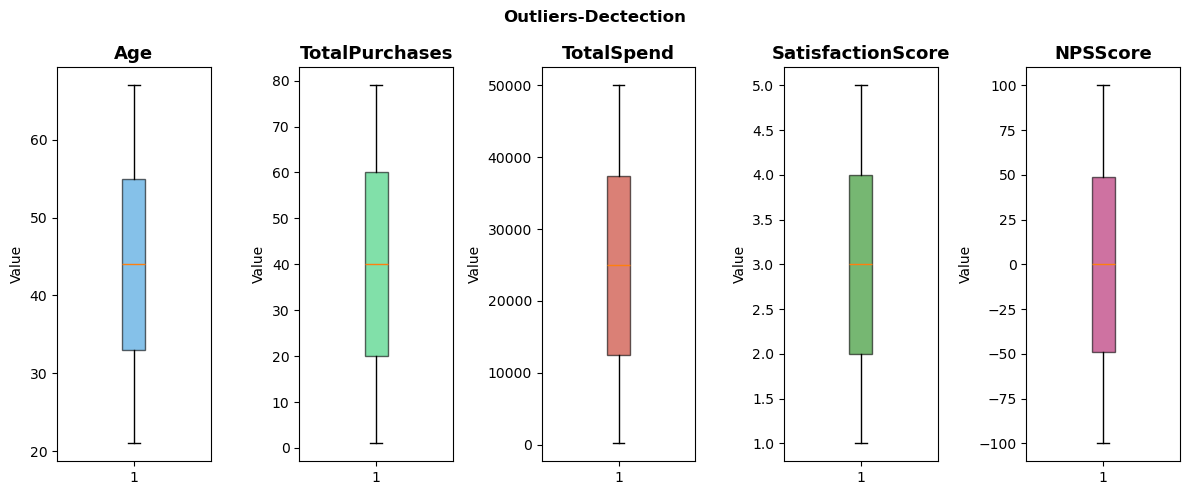

In [22]:
fig,axes=plt.subplots(1,5,figsize=(12,5))

columns=['Age','TotalPurchases','TotalSpend','SatisfactionScore','NPSScore']
colors=['#3498db','#2ecc71',"#c22b1b","#1b8815","#ae1562"]


for ax,col,color in zip(axes,columns,colors):
    ax.boxplot(df[col].dropna(),patch_artist=True,boxprops=dict(facecolor=color,alpha=0.6))
    ax.set_title(f'{col}',fontsize=13,fontweight='bold')
    ax.set_ylabel('Value')
plt.suptitle('Outliers-Dectection',fontweight='bold')
plt.tight_layout()
plt.show()

### KPI's Based on Business Requirements.

In [33]:
Total_Sales =  df['TotalSpend'].agg(['sum','mean','max','min'])
print(f'Total Sales by the Customers {Total_Sales}')

Total Sales by the Customers sum    1248698179.44
mean        24973.96
max         49999.82
min           201.00
Name: TotalSpend, dtype: float64


In [36]:
AvgOrderValues = (df['TotalSpend'] / df['TotalPurchases'])
print(f'The AvgOrderValues is {AvgOrderValues}')

The AvgOrderValues is 0       1270.36
1       1345.99
2        333.20
3       1435.57
4        527.93
          ...  
49995   6356.45
49996    438.44
49997    172.15
49998     96.11
49999    257.24
Length: 50000, dtype: float64


In [38]:
UniqueCustomer=df['CustomerID'].nunique()
print(f'The Number of Unique Customers in business are {UniqueCustomer}')

The Number of Unique Customers in business are 50000


In [40]:
Repeated_Customers= (df['CustomerID'].value_counts()>1).sum()
print(f'The Repeated or loyal Customers to the Business are {Repeated_Customers}')

The Repeated or loyal Customers to the Business are 0


In [44]:
ChurnRate = round((df['Churn'].eq(1).sum() / df['CustomerID'].nunique()) *100 ,2)
print(f'The Total ChurnRate in Business {ChurnRate}')


The Total ChurnRate in Business 30.65


In [48]:
Non_Churn = round((df['Churn'].eq(0).sum() / df['CustomerID'].nunique()) *100 ,2)
print(f'The Total Non_ChurnRate customers in Business {Non_Churn}')


The Total Non_ChurnRate customers in Business 69.35


### Univariate Analysis on Gender Column to show how many Male,Female and others customers are there in data using Pie Chart.

#### Pie chart on Gender column shows that female customers are 50% & male customers with 49.9% , and 'Other' gender are 2% , indicating highest female customers in this dataset. 

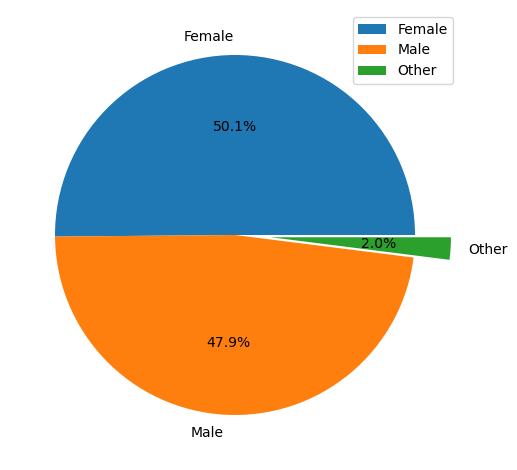

In [23]:
Gender_count=df['Gender'].value_counts()
plt.pie(Gender_count,labels=Gender_count.index,autopct="%1.1f%%",explode=[0,0,0.2])
plt.legend()
plt.tight_layout()
plt.show()

### Univariate Analysis on Gender Column based on TotalSpend amount using Bar Chart to visualize customers spending by gender.

#### The bar chart shows that female customers contribute the highest total purchase amount (over 60,000), followed by male customers around (56,000) while 'Other' category has the lowest contribution around (3000).Hence the female customers contribute the most to all over purchases in the dataset. 

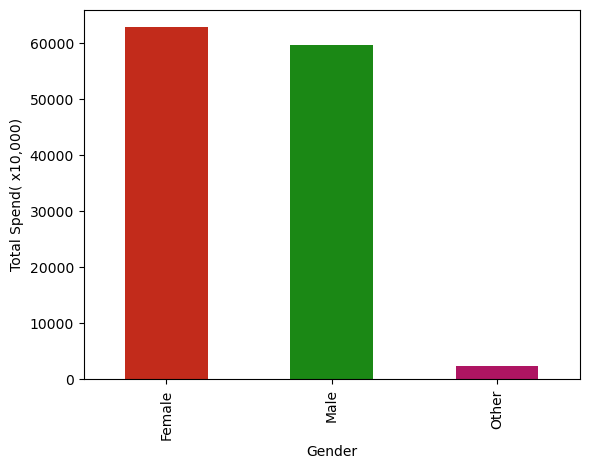

In [24]:
TotalPurchases_Gender=df.groupby('Gender')['TotalSpend'].sum() / 10000
TotalPurchases_Gender.sort_values(ascending=False).plot(kind='bar',color=["#c22b1b","#1b8815","#ae1562"])
plt.ylabel('Total Spend( x10,000)')
plt.ticklabel_format(style='plain',axis='y')
plt.show()

### Bivariate Analysis of Gender vs Churn to compare how many customers from each gender gave reviews values of 0 & 1 using Clustered Bar Chart.

#### The cluster bar chart shows that female customers have the highest number of non-Churned customers, followed closely by male customers. The 'Other' gender category has the lowest number of non-Churn customers, indicating that the customer retention is the highest among female customers in this dataset. 

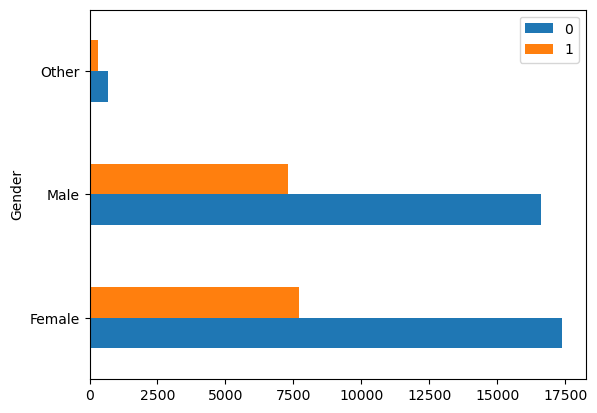

In [25]:
pd.crosstab(df['Gender'],df['Churn']).plot(kind='barh')
plt.legend()
plt.show()

### Bivaiate Analysis of Age & AvgOrderValue using Scatter plot to visualize the relationship between customer Age & AvgOrderValue.

#### The scatter plot shows a random distribution of data points with no clear upward or downward trend. Indicates the customer age doesn't appear to have a significant impact on the average order value in this dataset.

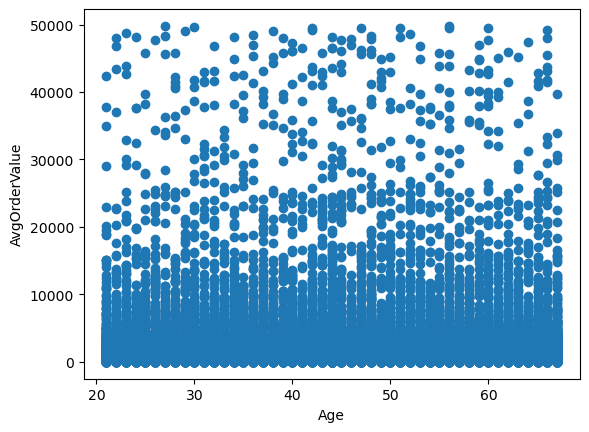

In [26]:
plt.scatter(df['Age'],df['AvgOrderValue'])
plt.xlabel('Age')
plt.ylabel('AvgOrderValue')
plt.show()

#### Line chart to show the trends.

#### The line chart shows an upward trend in totalSpend for female customers compared to male and other gender group, indicating the female customer have the highest purchase contribution.

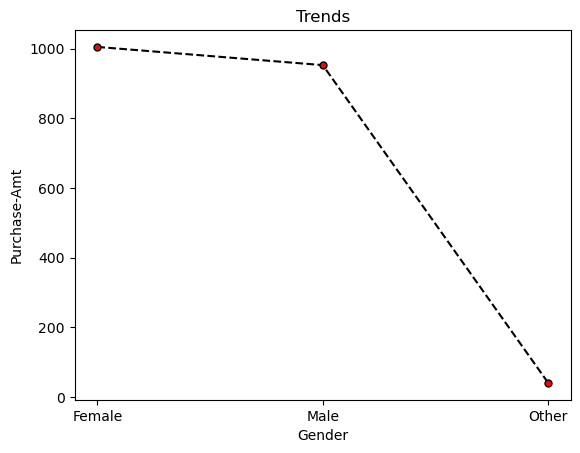

In [27]:
line_plot=df.groupby('Gender')['TotalPurchases'].sum()/1000
line_style=dict(marker=".",markersize=10,markerfacecolor="Red",markeredgecolor="black",linestyle="dashed",color="black")
plt.plot(line_plot,**line_style)
plt.title("Trends")
plt.xlabel("Gender")
plt.ylabel("Purchase-Amt")
plt.show()

#### Heatmap using Seaborn library.

#### The heatmap indicates that most features have weak correlations. The strongest negative relationship is between total purchases and average order value that is (-0.43), while total spend and average value show a weak positive correlation (0.23), the Churn is weakly negative correlated with satisfactionScore and NPSScore suggesting slightly lower Churn among more satisfied customers.

<Axes: >

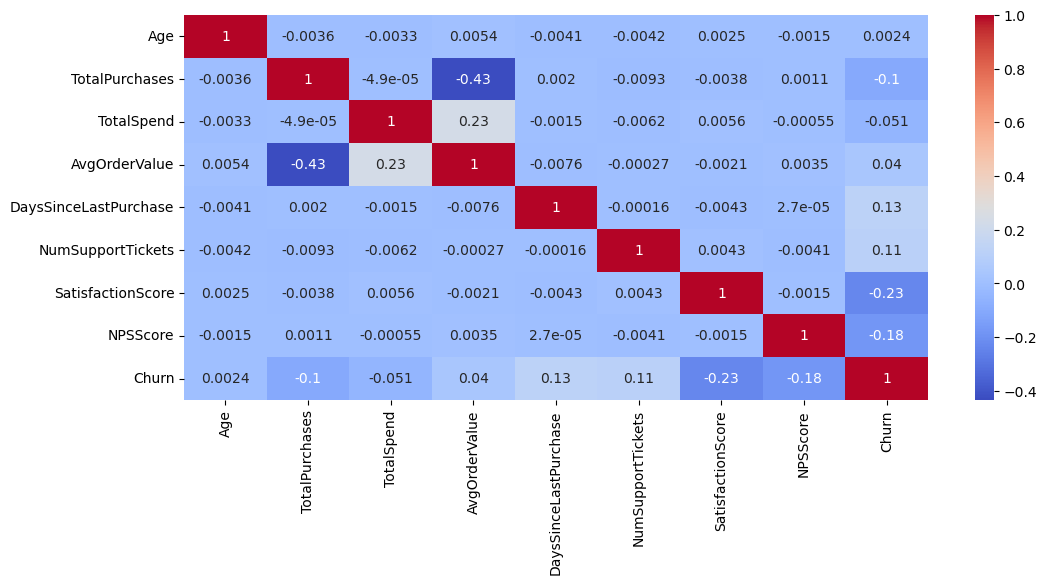

In [28]:
corr=df.corr(numeric_only=True)
fig,ax=plt.subplots(figsize=(12,5))

sns.heatmap(corr,annot=True,cmap='coolwarm')

### Positive Review From the Customers based on CustomerSegements.

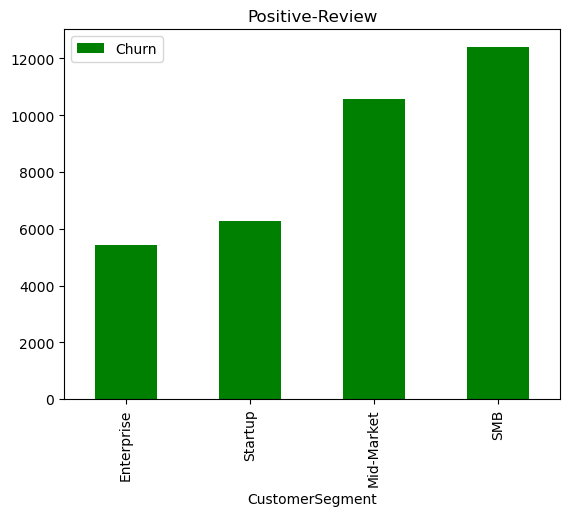

In [29]:
Positive_Review=pd.pivot_table(df[df['Churn']==0],index='CustomerSegment',values='Churn',aggfunc='count')
Positive_Review = Positive_Review.sort_values(by='Churn',ascending=True)
Positive_Review.plot(kind='bar',color='green')
plt.title('Positive-Review')
plt.show()

### Negative Review From the Customers based on CustomerSegements.

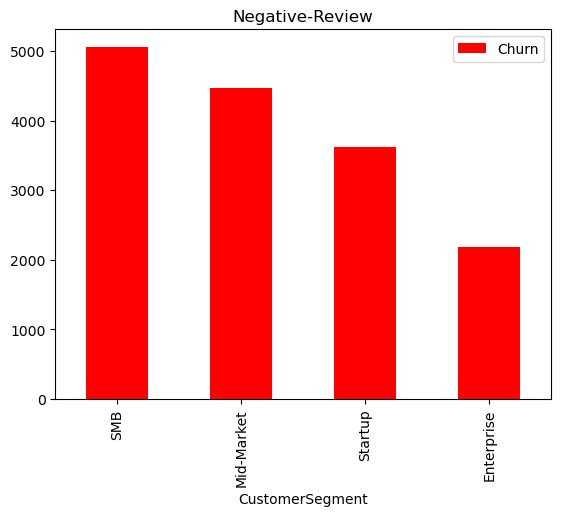

In [30]:
Negative_Review=pd.pivot_table(df[df['Churn']==1],index='CustomerSegment',values='Churn',aggfunc='count')
Negative_Review = Negative_Review.sort_values(by='Churn',ascending=False)
Negative_Review.plot(kind='bar',color='red')
plt.title('Negative-Review')
plt.show()

### Connecting the Dataset to SQL Server Using SSMS.

In [31]:
from sqlalchemy import create_engine

engine=create_engine("mssql+pyodbc://localhost\\SQLEXPRESS/CustomerDB?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes")

df.to_sql("churn_info",engine,if_exists="replace",index=False)

c:\Users\Naveed Sultan\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


4

### The data set was clean transformed and analyzed using Python, various visualizations were created to identify customer purchase patterns, demographics and Churn behavior. The analysis highlighted key business insights including higher spending by female customers and weak correlations among most variables. Overall , the project demonstrate a complete EDA-workflow and supports data-driven decision making.